In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../datasets/raw/diabetes.csv")
print(df.shape)

(100000, 9)


In [26]:
print(df.columns)
print(df.info())
print(df.describe().T)

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB
None
                        count        mean        std    min     25%     50%  \
age                  100000.0   41.8858

* Check for Duplicates

In [27]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 3854


**drop duplicates**

In [28]:
df.drop_duplicates()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99994,Female,36.0,0,0,No Info,24.60,4.8,145,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


* Uniqueness

In [29]:
for column in df.columns:
    distinct = len(df[column].unique())
    print(f"{column}: {distinct} distinct values")

gender: 3 distinct values
age: 102 distinct values
hypertension: 2 distinct values
heart_disease: 2 distinct values
smoking_history: 6 distinct values
bmi: 4247 distinct values
HbA1c_level: 18 distinct values
blood_glucose_level: 18 distinct values
diabetes: 2 distinct values


### Univariate Analysis

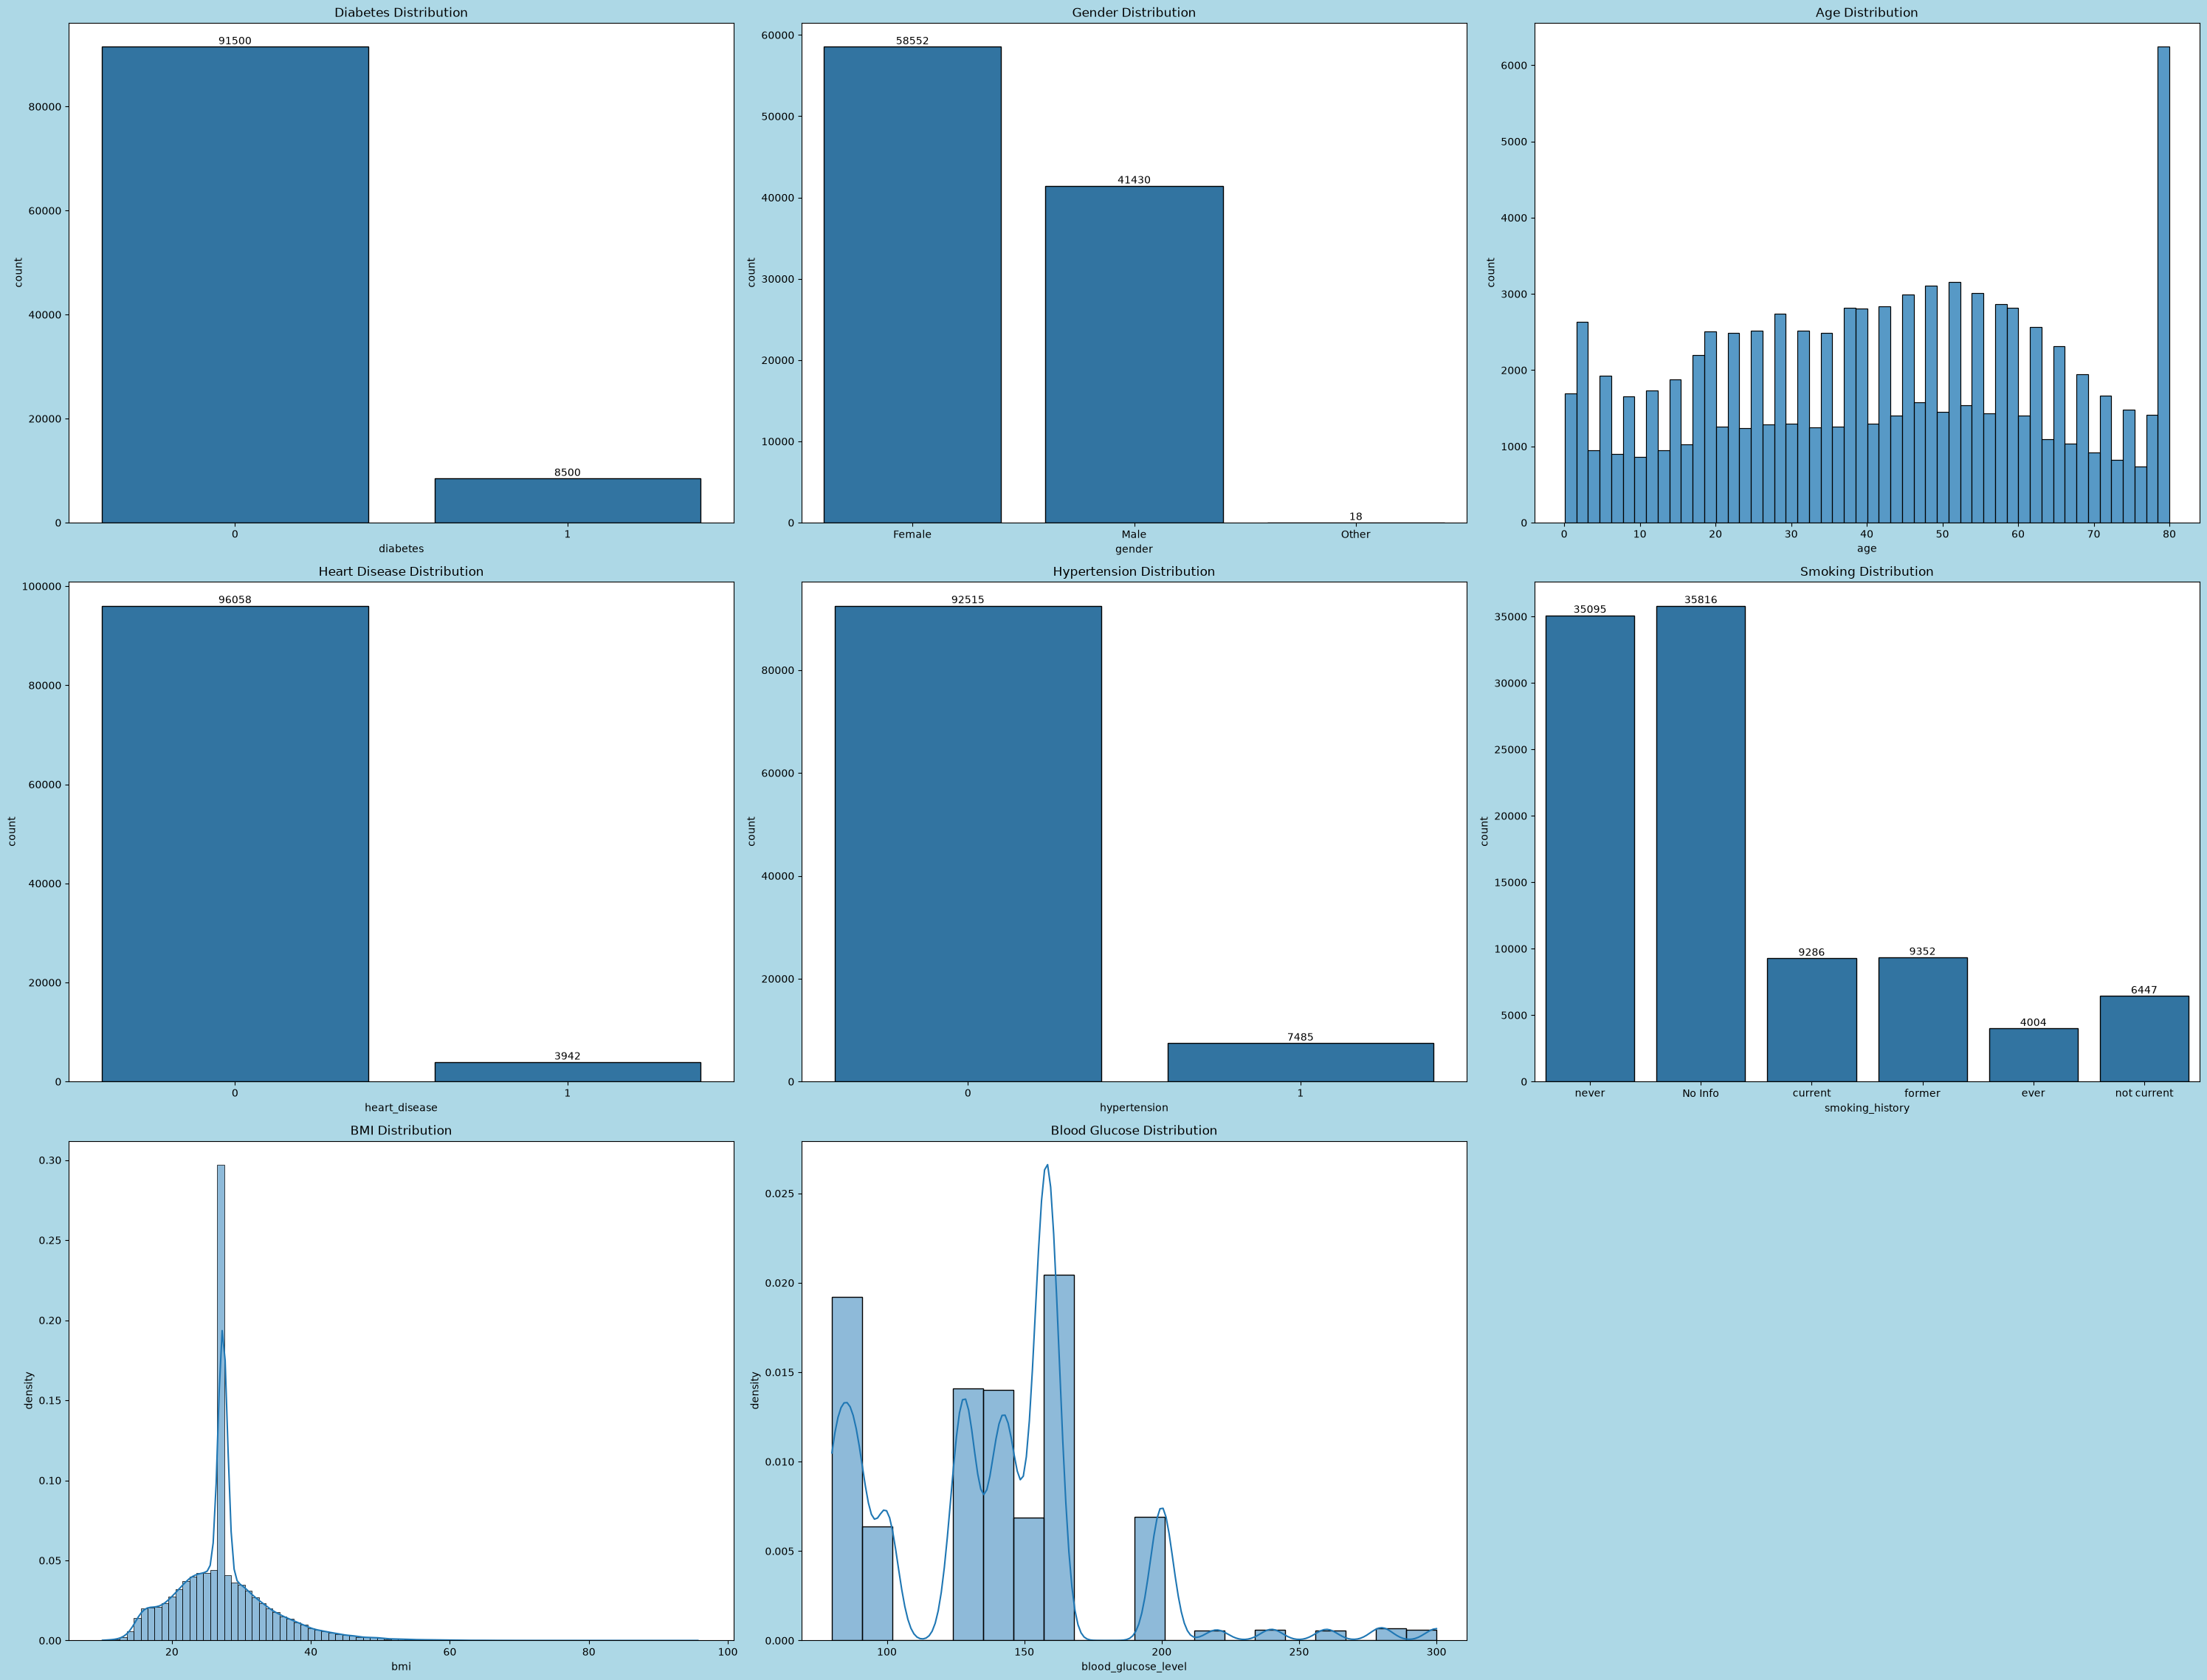

In [30]:
plt.figure(figsize=(30,30), facecolor="lightblue")

plt.subplot(4,3,1)
ax = sns.countplot(data=df, x="diabetes", edgecolor="black")
ax.bar_label(ax.containers[0]) # type: ignore
plt.title("Diabetes Distribution")

plt.subplot(4,3,2)
ax = sns.countplot(data=df, x="gender", edgecolor="black")
ax.bar_label(ax.containers[0]) # type: ignore
plt.xlabel("gender")
plt.ylabel("count")
plt.title("Gender Distribution")

plt.subplot(4,3,3)
sns.histplot(data=df, x="age", edgecolor="black")
plt.xlabel("age")
plt.ylabel("count")
plt.title("Age Distribution")

plt.subplot(4,3,4)
ax = sns.countplot(data=df, x="heart_disease", edgecolor="black")
ax.bar_label(ax.containers[0]) # type: ignore
plt.title("Heart Disease Distribution")

plt.subplot(4,3,5)
ax = sns.countplot(data=df, x="hypertension", edgecolor="black")
ax.bar_label(ax.containers[0]) # type: ignore
plt.title("Hypertension Distribution")

plt.subplot(4,3,6)
ax = sns.countplot(data=df, x="smoking_history", edgecolor="black")
ax.bar_label(ax.containers[0]) # type: ignore
plt.title("Smoking Distribution")

plt.subplot(4,3,7)
sns.histplot(data=df, x="bmi", discrete=True, stat="density", kde=True)
plt.xlabel("bmi")
plt.ylabel("density")
plt.title("BMI Distribution")

plt.subplot(4,3,8)
sns.histplot(data=df, x="blood_glucose_level", bins=20, stat="density", kde=True)
plt.xlabel("blood_glucose_level")
plt.ylabel("density")
plt.title("Blood Glucose Distribution")

plt.tight_layout()
plt.show()

### Bivariate Analysis

In [31]:
gender_diabetes = (
    df.groupby("gender")["diabetes"]
    .aggregate(["mean", "count"])
    .rename(columns={"count": "Total", "mean": "Diabetes Rate"})
    )
print(gender_diabetes)

        Diabetes Rate  Total
gender                      
Female       0.076189  58552
Male         0.097490  41430
Other        0.000000     18


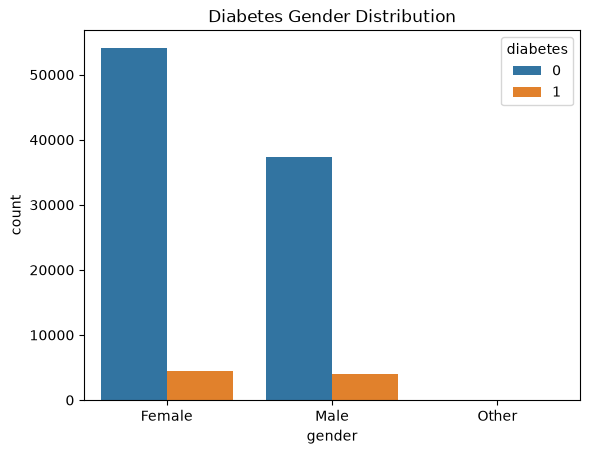

In [32]:
sns.countplot(data=df, x="gender", hue="diabetes")
plt.title("Diabetes Gender Distribution")
plt.show()

In [33]:
smoking_gender = (
    df.groupby(["gender", "smoking_history"])["diabetes"]
    .agg(["mean", "count"])
    .rename(columns={"mean":"Diabetes Rate", "count":"Total"})
    )
print(smoking_gender)

                        Diabetes Rate  Total
gender smoking_history                      
Female No Info               0.038274  19700
       current               0.089166   5058
       ever                  0.094281   2238
       former                0.135945   4774
       never                 0.087542  22869
       not current           0.100690   3913
Male   No Info               0.043451  16110
       current               0.117550   4228
       ever                  0.147875   1765
       former                0.205548   4578
       never                 0.109957  12223
       not current           0.117181   2526
Other  No Info               0.000000      6
       ever                  0.000000      1
       never                 0.000000      3
       not current           0.000000      8


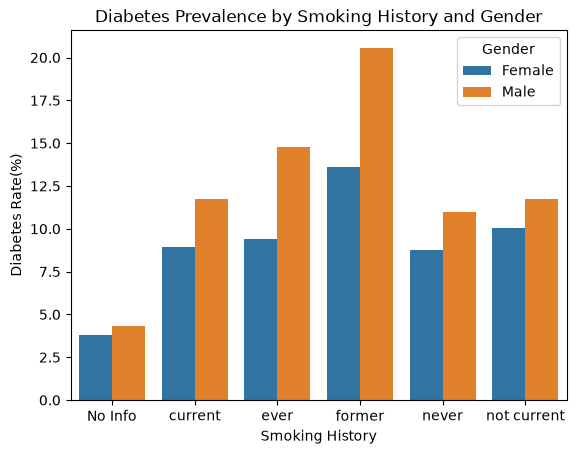

In [34]:
smoking_gender = (
    df.groupby(["smoking_history", "gender"])["diabetes"]
      .mean()
      .reset_index()
)
smoking_gender["diabetes"] *= 100
smoking_gender = smoking_gender[smoking_gender["gender"] != "Other"]
sns.barplot(data=smoking_gender, x="smoking_history", y="diabetes", hue="gender")
plt.title("Diabetes Prevalence by Smoking History and Gender")
plt.xlabel("Smoking History")
plt.ylabel("Diabetes Rate(%)")
plt.legend(title="Gender")
plt.show()

* Diabetes prevalence varies across smoking-history categories, with former smokers showing the highest observed prevalence in both female and male groups. The pattern also differs across gender as within almost every comparable smoking category, males have a higher observed diabetes rate.

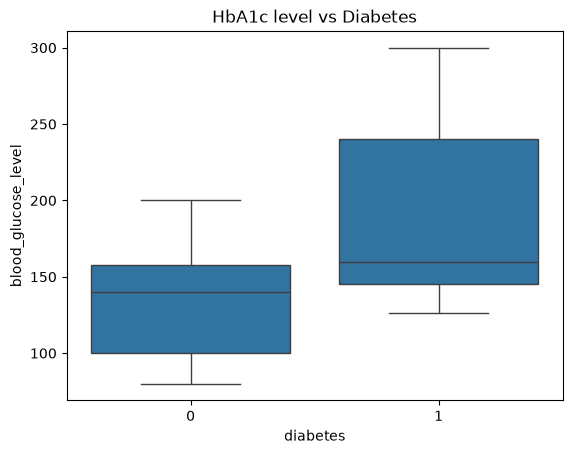

In [35]:
sns.boxplot(data=df, x='diabetes', y='blood_glucose_level')
plt.title('HbA1c level vs Diabetes')
plt.show()